In [ ]:
# BLOCK 1: Setup and Imports
from tqdm.auto import tqdm
from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    lit,
    col,
    udf,
    explode,
    create_map,
    size,
    stddev,
    round as spark_round,
    mean,
    min as spark_min,
    max as spark_max,
)
from tabulate import tabulate

import pyspark.sql.types as data_type
# import warnings
# warnings.filterwarnings('ignore')

In [2]:
# Global configuration - CHANGE THESE PATHS
ROOT_DIR = Path("~/Documents/sr_proj/PolypDetection").expanduser()
IMAGES_PATH = ROOT_DIR / "data/raw/Kvasir-SEG/images"
MASKS_PATH = ROOT_DIR / "data/raw/Kvasir-SEG/masks"
BBOX_JSON_PATH = ROOT_DIR / "data/raw/Kvasir-SEG/kavsir_bboxes.json"

for path in [IMAGES_PATH,MASKS_PATH,BBOX_JSON_PATH]:
    print(f"{path} : {path.exists()}")

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Create output directory
# OUTPUT_DIR = ROOT_DIR / "models" / Path.cwd().name
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Output directory created: {OUTPUT_DIR}")

# Initialize Spark Session
print("Creating Spark session...")
spark = (
    SparkSession.builder.appName("PolypDatasetAnalysis")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .master("local[*]")
    .getOrCreate()
)
print(f"Spark session created! Version: {spark.version}")
print("Visit : http://localhost:4040")

/home/srirama/Documents/sr_proj/PolypDetection/data/raw/Kvasir-SEG/images : True
/home/srirama/Documents/sr_proj/PolypDetection/data/raw/Kvasir-SEG/masks : True
/home/srirama/Documents/sr_proj/PolypDetection/data/raw/Kvasir-SEG/kavsir_bboxes.json : True
Output directory created: /home/srirama/Documents/sr_proj/PolypDetection/notebooks/1-explore/outputs
Creating Spark session...


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/26 07:15:20 WARN Utils: Your hostname, ASUS-TUF-Gaming-A15-FA506NFR-FA506NFR, resolves to a loopback address: 127.0.1.1; using 192.168.1.4 instead (on interface wlp3s0)
26/04/26 07:15:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 07:15:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session created! Version: 4.1.1
Visit : http://localhost:4040


In [6]:
# BLOCK 2: Load and Validate Dataset Structure
# Get all image files
image_files = list(IMAGES_PATH.glob("*.jpg")) + list(IMAGES_PATH.glob("*.png"))
print(f"Found {len(image_files)} images")

# Load bounding box JSON
print("Loading bounding box annotations...")
with open(BBOX_JSON_PATH, "r") as f:
    bbox_data = json.load(f)
print(f"Loaded {len(bbox_data)} image annotations from JSON")

# Create mapping from image name to bbox info
image_to_bbox = {}
for img_id, bbox_info in tqdm(bbox_data.items(),desc="Mapping Image File ID to Boxes"):
    # The key in JSON is the filename without extension
    image_to_bbox[img_id] = {
        "height": bbox_info["height"],
        "width": bbox_info["width"],
        "bboxes": bbox_info["bbox"],
    }

# Create list of images that have both image file and bbox annotation
valid_images = []
for img_path in image_files:
    img_name = img_path.stem
    if img_name in image_to_bbox:
        valid_images.append((img_name, img_path))

print(f"Valid images (have both file + annotation): {len(valid_images)}")

# Create sample DataFrame for validation
sample_df = pd.DataFrame(valid_images[:5], columns=["image_id", "path"])
print(sample_df.to_string())

Found 1000 images
Loading bounding box annotations...
Loaded 1000 image annotations from JSON


Mapping Image File ID to Boxes:   0%|          | 0/1000 [00:00<?, ?it/s]

Valid images (have both file + annotation): 1000
                    image_id                                                                                                     path
0  cju439oazm2fu0871ma0vvrft  /home/srirama/Documents/sr_proj/PolypDetection/data/raw/Kvasir-SEG/images/cju439oazm2fu0871ma0vvrft.jpg
1  cju5ukkg6kv7u08011x2b6zl5  /home/srirama/Documents/sr_proj/PolypDetection/data/raw/Kvasir-SEG/images/cju5ukkg6kv7u08011x2b6zl5.jpg
2  cju1b3zgj3d8e0801kpolea6c  /home/srirama/Documents/sr_proj/PolypDetection/data/raw/Kvasir-SEG/images/cju1b3zgj3d8e0801kpolea6c.jpg
3  cju88y1mwoln50871emyfny1g  /home/srirama/Documents/sr_proj/PolypDetection/data/raw/Kvasir-SEG/images/cju88y1mwoln50871emyfny1g.jpg
4  cju2wve9v7esz0878mxsdcy04  /home/srirama/Documents/sr_proj/PolypDetection/data/raw/Kvasir-SEG/images/cju2wve9v7esz0878mxsdcy04.jpg


In [7]:
import cv2
from scipy import stats
from skimage.measure import shannon_entropy
# BLOCK 3: Fixed - Spark DataFrame Creation with Proper Type Conversion
# Function to extract features from an image using PIL


def extract_image_stats(image_path_str):
    """
    Extract image-level statistics.
    Returns Python-native dictionary.
    """
    try:
        img = Image.open(image_path_str).convert("RGB")
        img_array = np.array(img)
        height = int(img_array.shape[0])
        width = int(img_array.shape[1])

        # Global intensity statistics
        flat = img_array.flatten()
        brightness_mean = float(np.mean(flat))
        contrast_std = float(np.std(flat))
        skewness = float(stats.skew(flat))
        kurtosis = float(stats.kurtosis(flat))

        # Channel statistics
        r = img_array[:, :, 0]
        g = img_array[:, :, 1]
        b = img_array[:, :, 2]
        mean_r = float(np.mean(r))
        mean_g = float(np.mean(g))
        mean_b = float(np.mean(b))
        std_r = float(np.std(r))
        std_g = float(np.std(g))
        std_b = float(np.std(b))

        # Entropy
        entropy = float(shannon_entropy(img_array))
        # Blur score
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        blur_score = float(cv2.Laplacian(gray, cv2.CV_64F).var())
        # Specular highlight ratio
        # pixels nearly saturated
        highlights = np.all(img_array > 245, axis=2)
        specular_ratio = float(np.mean(highlights))

        return {
            "image_height": height,
            "image_width": width,
            "brightness_mean": brightness_mean,
            "contrast_std": contrast_std,
            "skewness": skewness,
            "kurtosis": kurtosis,
            "entropy": entropy,
            "blur_score": blur_score,
            "specular_ratio": specular_ratio,
            "mean_r": mean_r,
            "mean_g": mean_g,
            "mean_b": mean_b,
            "std_r": std_r,
            "std_g": std_g,
            "std_b": std_b,
        }

    except Exception as e:
        print(f"Error processing {image_path_str}: {e}")

        return {
            "image_height": 0,
            "image_width": 0,
            "brightness_mean": 0.0,
            "contrast_std": 0.0,
            "skewness": 0.0,
            "kurtosis": 0.0,
            "entropy": 0.0,
            "blur_score": 0.0,
            "specular_ratio": 0.0,
            "mean_r": 0.0,
            "mean_g": 0.0,
            "mean_b": 0.0,
            "std_r": 0.0,
            "std_g": 0.0,
            "std_b": 0.0,
        }

# Create list of image data with explicit Python types
image_data = []
for img_id, img_path in tqdm(valid_images, desc="Processing images"):
    img_info = image_to_bbox[img_id]
    stats_dict = extract_image_stats(str(img_path))

    # For each bounding box (polyp) in the image
    for bbox_idx, bbox in enumerate(img_info["bboxes"]):
        # Calculate bounding box area - ensure Python ints
        bbox_width = int(bbox["xmax"] - bbox["xmin"])
        bbox_height = int(bbox["ymax"] - bbox["ymin"])
        bbox_area = int(bbox_width * bbox_height)

        # Create dictionary with explicit Python native types
        image_data.append(
            {
                "image_id": str(img_id),
                "image_path": str(img_path),
                "polyp_index": int(bbox_idx),
                "image_height": stats_dict["image_height"],
                "image_width": stats_dict["image_width"],
                "bbox_xmin": int(bbox["xmin"]),
                "bbox_ymin": int(bbox["ymin"]),
                "bbox_xmax": int(bbox["xmax"]),
                "bbox_ymax": int(bbox["ymax"]),
                "bbox_width": bbox_width,
                "bbox_height": bbox_height,
                "bbox_area": bbox_area,
                "image_brightness_mean": stats_dict["brightness_mean"],
                "image_contrast_std": stats_dict["contrast_std"],
                "image_skewness": stats_dict["skewness"],
                "image_kurtosis": stats_dict["kurtosis"],
                "image_entropy": stats_dict["entropy"],
                "image_blur_score": stats_dict["blur_score"],
                "specular_ratio": stats_dict["specular_ratio"],
                "mean_r": stats_dict["mean_r"],
                "mean_g": stats_dict["mean_g"],
                "mean_b": stats_dict["mean_b"],
                "std_r": stats_dict["std_r"],
                "std_g": stats_dict["std_g"],
                "std_b": stats_dict["std_b"],
                "label": str(bbox.get("label", "polyp")),
            }
        )

print(f"Collected {len(image_data)} polyp instances with native Python types")

# Convert to Spark DataFrame - now it will work!
spark_df = spark.createDataFrame(image_data)
spark_df.describe().show()
print("Spark DataFrame Schema:")
spark_df.printSchema()
print("Sample of Spark DataFrame (first 5 rows):")
spark_df.show(5, truncate=False)

Processing images:   0%|          | 0/1000 [00:00<?, ?it/s]

Collected 1071 polyp instances with native Python types


26/04/26 07:23:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+---------------------+------------------+------------------+-----------------+--------------------+-------------------+--------------------+-------------------+------------------+-----+------------------+------------------+------------------+-------------------+--------------------+------------------+-----------------+------------------+
|summary|        bbox_area|       bbox_height|        bbox_width|         bbox_xmax|         bbox_xmin|         bbox_ymax|         bbox_ymin|  image_blur_score|image_brightness_mean|image_contrast_std|     image_entropy|     image_height|            image_id|     image_kurtosis|          image_path|     image_skewness|       image_width|label|            mean_b|            mean_g|            mean_r|        polyp_index|      specular_ratio|             std_b|            std_g|             std_r|


In [8]:
# BLOCK 4: Calculate Advanced Metrics with Rich Mask Statistics
from skimage.measure import label, regionprops
import numpy as np

# Add relative bounding box area (polyp size relative to image size)
spark_df = spark_df.withColumn(
    "relative_bbox_area", col("bbox_area") / (col("image_width") * col("image_height"))
)  # relative_bbox_area: What fraction of the entire image does the bounding box occupy? Range 0-1. Smaller values mean tiny polyps.

print("Checking for mask files...")
mask_files = list(MASKS_PATH.glob("*.png")) + list(MASKS_PATH.glob("*.jpg"))


def extract_mask_stats(mask_path):
    """
    Extract comprehensive shape statistics from a segmentation mask.
    Returns dict with various geometric properties of the polyp region.
    """
    try:
        # Load mask as numpy array
        mask = np.array(Image.open(mask_path))
        if mask.ndim == 3:  # Convert to grayscale if RGB
            mask = mask[:, :, 0]  # Take first channel only
        # Create binary mask (assuming polyp pixels have value > 0)
        binary = (mask > 0).astype(np.uint8)  # Converting boolean array to 0-255
        # Calculate basic area (number of polyp pixels)
        area = int(
            binary.sum()
        )  # mask_area: Total number of pixels belonging to the polyp
        # Label connected components (separate regions)
        labeled = label(binary)  # Labels each connected region with a unique number
        props = regionprops(labeled)  # Extract properties of each region

        if len(props) == 0:
            raise ValueError("Empty mask")

        # Select the largest region (main polyp)
        region = max(props, key=lambda r: r.area)
        # Perimeter: Length of the polyp's boundary in pixels
        perimeter = float(region.perimeter)
        # Circularity: How round the polyp is. Range 0-1. 1 = perfect circle, lower = more irregular
        circularity = float(4 * np.pi * region.area / (perimeter**2 + 1e-8))
        # Solidity: Ratio of polyp area to its convex hull area. Range 0-1.
        # 1 = perfectly convex (no indentations), lower = more irregular/lobulated shape
        solidity = float(region.solidity)
        # Eccentricity: How elongated the polyp is. Range 0-1.
        # 0 = perfect circle, values near 1 = very elongated/oval shaped
        eccentricity = float(region.eccentricity)
        # Extent: Ratio of polyp area to its bounding box area. Range 0-1.
        # Shows how much of the bounding box is filled by the polyp
        extent = float(region.extent)
        # Additional useful metrics
        # Major axis length: Length of the longest line through the polyp (in pixels)
        major_axis_length = float(region.axis_major_length)
        # Minor axis length: Length of the shortest line through the polyp (in pixels)
        minor_axis_length = float(region.axis_minor_length)
        # Equivalent diameter: Diameter of a circle with the same area as the polyp
        equivalent_diameter = float(region.equivalent_diameter_area)

        return {
            "mask_area": area,  # Number of pixels in the polyp segmentation
            "mask_perimeter": perimeter,  # Boundary length in pixels
            "mask_circularity": circularity,  # 1=perfect circle, <1=irregular
            "mask_solidity": solidity,  # 1=convex shape, <1=has indentations
            "mask_eccentricity": eccentricity,  # 0=circle, >0=elongated
            "mask_extent": extent,  # Polyp area / bounding box area
            "mask_major_axis": major_axis_length,  # Longest diameter through polyp
            "mask_minor_axis": minor_axis_length,  # Shortest diameter through polyp
            "mask_eq_diameter": equivalent_diameter,  # Diameter of equal-area circle
        }
    except Exception as _:
        # Return zeros for all metrics if mask processing fails
        return {
            "mask_area": 0,
            "mask_perimeter": 0.0,
            "mask_circularity": 0.0,
            "mask_solidity": 0.0,
            "mask_eccentricity": 0.0,
            "mask_extent": 0.0,
            "mask_major_axis": 0.0,
            "mask_minor_axis": 0.0,
            "mask_eq_diameter": 0.0,
        }


print(f"Found {len(mask_files)} mask files. Calculating advanced mask statistics...")
# Process each image and extract mask statistics
mask_stats_list = []
spark_data = (
    spark_df.collect()
)  # Collect Spark data for processing (fine for 1000 images)

for row in tqdm(spark_data, desc="Extracting mask features"):
    # Construct mask path - adjust based on your file naming convention
    mask_path = MASKS_PATH / f"{row['image_id']}.jpg"
    if mask_path:
        # Extract all mask statistics
        mask_stats = extract_mask_stats(str(mask_path))
        mask_stats_list.append(
            {
                "image_id": row["image_id"],
                "polyp_index": row["polyp_index"],
                "mask_path": str(mask_path),
                **mask_stats,  # Unpack all the mask metrics
            }
        )
    else:
        # No mask found - fill with zeros
        mask_stats_list.append(
            {
                "image_id": row["image_id"],
                "polyp_index": row["polyp_index"],
                "mask_path": None,
                "mask_area": 0,
                "mask_perimeter": 0.0,
                "mask_circularity": 0.0,
                "mask_solidity": 0.0,
                "mask_eccentricity": 0.0,
                "mask_extent": 0.0,
                "mask_major_axis": 0.0,
                "mask_minor_axis": 0.0,
                "mask_eq_diameter": 0.0,
            }
        )

Checking for mask files...
Found 1000 mask files. Calculating advanced mask statistics...


Extracting mask features:   0%|          | 0/1071 [00:00<?, ?it/s]

In [9]:
# Convert to Spark DataFrame and join with original data
mask_stats_df = spark.createDataFrame(mask_stats_list)
spark_df = spark_df.join(mask_stats_df, on=["image_id", "polyp_index"], how="left")

# Add derived metrics comparing bounding box and mask
spark_df = spark_df.withColumn(
    "relative_mask_area", col("mask_area") / (col("image_width") * col("image_height"))
)  # relative_mask_area: What fraction of the entire image is occupied by the polyp? Smaller values mean polyp is tiny relative to image.

spark_df = spark_df.withColumn(
    "bbox_vs_mask_area_diff", col("bbox_area") - col("mask_area")
)  # bbox_vs_mask_area_diff: Difference between bounding box area and mask area. Positive means box is larger than polyp (has extra background). Zero means perfect fit.

spark_df = spark_df.withColumn(
    "mask_vs_bbox_area_ratio", col("mask_area") / col("bbox_area")
)  # mask_vs_bbox_area_ratio: What fraction of the bounding box is actually polyp? Range 0-1. Higher values mean tighter bounding box. Lower values mean lots of background in the box.

# Calculate bounding box aspect ratio
spark_df = spark_df.withColumn(
    "bbox_aspect_ratio", col("bbox_width") / col("bbox_height")
)  # bbox_aspect_ratio: Width/height ratio of bounding box. 1 = square, >1 = wide rectangle, <1 = tall rectangle.

# Filter to only rows with valid masks (area > 0)
valid_masks_df = spark_df.filter(col("mask_area") > 0)

if valid_masks_df.count() > 0:
    print("\nMask Area Statistics (pixels):")
    valid_masks_df.describe().show()
else:
    print("No valid masks found. Check your mask file paths and naming convention.")

print("UPDATED DATAFRAME SCHEMA")
spark_df.printSchema()

# Average shape characteristics
avg_circularity = valid_masks_df.selectExpr("avg(mask_circularity)").collect()[0][0]
avg_solidity = valid_masks_df.selectExpr("avg(mask_solidity)").collect()[0][0]
avg_eccentricity = valid_masks_df.selectExpr("avg(mask_eccentricity)").collect()[0][0]

print(
    f"Average Polyp Circularity: {avg_circularity:.3f} (1=perfect circle, <1=irregular)"
)
print(
    f"Average Polyp Solidity: {avg_solidity:.3f} (1=convex, <1=has indentations/lobulations)"
)
print(f"Average Polyp Eccentricity: {avg_eccentricity:.3f} (0=circle, >0=elongated)")

# Classification based on shape
# Irregular polyps (low circularity and low solidity) might indicate malignancy
irregular_threshold = 0.7  # Values below this considered irregular
num_irregular = valid_masks_df.filter(
    (col("mask_circularity") < irregular_threshold)
    | (col("mask_solidity") < irregular_threshold)
).count()
total_valid = valid_masks_df.count()
if total_valid > 0:
    pct_irregular = (num_irregular / total_valid) * 100
    print("\nPolyp Shape Analysis:")
    print(
        f"Polyps with irregular shape (circularity < {irregular_threshold} or solidity < {irregular_threshold}): {num_irregular} ({pct_irregular:.1f}%)"
    )
    print(
        "Note: Irregular shape can be associated with adenomatous or malignant polyps"
    )

# Size-based classification (Paris classification for polyps)
# Paris classification: 0-Ip (pedunculated), 0-Is (sessile), 0-IIa (slightly elevated), etc.
# Using relative size as proxy
small_polyps = valid_masks_df.filter(col("relative_bbox_area") < 0.01).count()
medium_polyps = valid_masks_df.filter(
    (col("relative_bbox_area") >= 0.01) & (col("relative_bbox_area") < 0.05)
).count()
large_polyps = valid_masks_df.filter(col("relative_bbox_area") >= 0.05).count()

print("\nPolyp Size Distribution (by relative area):")
print(
    f"Small polyps (<1% of image): {small_polyps} ({small_polyps / total_valid * 100:.1f}%)"
)
print(
    f"Medium polyps (1-5% of image): {medium_polyps} ({medium_polyps / total_valid * 100:.1f}%)"
)
print(
    f"Large polyps (>5% of image): {large_polyps} ({large_polyps / total_valid * 100:.1f}%)"
)


Mask Area Statistics (pixels):


+-------+--------------------+-------------------+-----------------+-----------------+------------------+------------------+------------------+-----------------+------------------+------------------+---------------------+------------------+------------------+-----------------+-------------------+--------------------+-------------------+------------------+-----+------------------+------------------+------------------+--------------------+------------------+------------------+------------------+--------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+------------------+--------------------+------------------+-------------------+--------------------+----------------------+-----------------------+--------------------+
|summary|            image_id|        polyp_index|        bbox_area|      bbox_height|        bbox_width|         bbox_xmax|         bbox_xmin|        bbox_ymax|         bbox_ymin|  image_blur_sc

Average Polyp Circularity: 0.233 (1=perfect circle, <1=irregular)
Average Polyp Solidity: 0.884 (1=convex, <1=has indentations/lobulations)
Average Polyp Eccentricity: 0.661 (0=circle, >0=elongated)

Polyp Shape Analysis:
Polyps with irregular shape (circularity < 0.7 or solidity < 0.7): 1071 (100.0%)
Note: Irregular shape can be associated with adenomatous or malignant polyps

Polyp Size Distribution (by relative area):
Small polyps (<1% of image): 26 (2.4%)
Medium polyps (1-5% of image): 145 (13.5%)
Large polyps (>5% of image): 900 (84.0%)


In [11]:
# BLOCK 6: Create Detailed CSV Output
# Convert Spark DataFrame to Pandas for easy CSV export
print("Converting to Pandas DataFrame (this may take a moment)...")
pandas_df = spark_df.toPandas()
# Sort for readability
pandas_df = pandas_df.sort_values(["image_id", "polyp_index"])

# Create unique ID for each polyp (image_id + polyp_index)
pandas_df["unique_polyp_id"] = (
    pandas_df["image_id"] + "_polyp_" + pandas_df["polyp_index"].astype(str)
)

# Save the detailed dataframe
detailed_csv_path = OUTPUT_DIR / "polyp_analysis_detailed.csv"
pandas_df.to_csv(detailed_csv_path, index=False)
print(f"Saved detailed analysis to {detailed_csv_path}")
print(f"File size: {detailed_csv_path.stat().st_size / 1024:.1f} KB")

Converting to Pandas DataFrame (this may take a moment)...


Saved detailed analysis to /home/srirama/Documents/sr_proj/PolypDetection/notebooks/1-explore/outputs/polyp_analysis_detailed.csv
File size: 829.3 KB


In [20]:
# BLOCK 6.5: Enhanced Statistics using Tabulate
# ============================================================================
# 1. BASIC DATASET OVERVIEW
# ============================================================================
print("\n📊 1. DATASET OVERVIEW")

total_images = pandas_df["image_id"].nunique()
total_polyps = len(pandas_df)
avg_polyps_per_image = total_polyps / total_images
single_polyp_images = pandas_df.groupby("image_id").size().value_counts().get(1, 0)
multi_polyp_images = total_images - single_polyp_images

overview_data = [
    ["Total Images", f"{total_images:,}"],
    ["Total Polyps", f"{total_polyps:,}"],
    ["Avg Polyps per Image", f"{avg_polyps_per_image:.2f}"],
    [
        "Single Polyp Images",
        f"{single_polyp_images} ({single_polyp_images / total_images * 100:.1f}%)",
    ],
    [
        "Multiple Polyp Images",
        f"{multi_polyp_images} ({multi_polyp_images / total_images * 100:.1f}%)",
    ],
    ["Images with Masks", f"{pandas_df['mask_path'].notna().sum():,}"],
]
print(tabulate(overview_data, headers=["Metric", "Value"], tablefmt="grid"))

# ============================================================================
# 2. POLYP SIZE STATISTICS (Bounding Box vs Mask)
# ============================================================================
print("\n📏 2. POLYP SIZE STATISTICS (pixels)")
size_stats = pandas_df[
    ["bbox_area", "mask_area", "relative_bbox_area", "relative_mask_area"]
].describe()
print(tabulate(size_stats, headers="keys", tablefmt="grid", floatfmt=".2f"))

# Bounding Box vs Mask comparison
valid_mask_df = pandas_df[pandas_df["mask_area"] > 0]
if len(valid_mask_df) > 0:
    print("\n📐 2.1 Bounding Box vs Mask Comparison")
    bbox_vs_mask = valid_mask_df[
        ["bbox_vs_mask_area_diff", "mask_vs_bbox_area_ratio"]
    ].describe()
    print(tabulate(bbox_vs_mask, headers="keys", tablefmt="grid", floatfmt=".2f"))

# ============================================================================
# 3. SHAPE CHARACTERISTICS
# ============================================================================
print("\n🟢 3. POLYP SHAPE CHARACTERISTICS")
shape_stats = pandas_df[
    [
        "bbox_aspect_ratio",
        "mask_circularity",
        "mask_eccentricity",
        "mask_solidity",
        "mask_extent",
    ]
].describe()
print(tabulate(shape_stats, headers="keys", tablefmt="grid", floatfmt=".3f"))

# ============================================================================
# 4. IMAGE QUALITY METRICS
# ============================================================================
print("\n🎨 4. IMAGE QUALITY METRICS")
quality_stats = pandas_df[
    [
        "image_brightness_mean",
        "image_contrast_std",
        "image_skewness",
        "image_kurtosis",
        "image_entropy",
        "image_blur_score",
    ]
].describe()
print(tabulate(quality_stats, headers="keys", tablefmt="grid", floatfmt=".3f"))

# ============================================================================
# 5. COLOR CHANNEL ANALYSIS (RGB)
# ============================================================================
print("\n🌈 5. RGB COLOR CHANNEL STATISTICS")
# Calculate mean RGB values per channel
rgb_stats = pandas_df[
    ["mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b"]
].describe()
print(tabulate(rgb_stats, headers="keys", tablefmt="grid", floatfmt=".2f"))

# Dominant channel analysis
pandas_df["dominant_channel"] = pandas_df[["mean_r", "mean_g", "mean_b"]].idxmax(axis=1)
dominant_counts = pandas_df["dominant_channel"].value_counts()
print("\nDominant Color Channel:")
print(
    tabulate(
        dominant_counts.reset_index(), headers=["Channel", "Count"], tablefmt="grid"
    )
)
# Specular highlights
print(
    f"\n💡 Specular Highlights Ratio: Mean = {pandas_df['specular_ratio'].mean():.3f}, "
    f"Std = {pandas_df['specular_ratio'].std():.3f}"
)

# ============================================================================
# 6. CORRELATION ANALYSIS (Top relationships)
# ============================================================================
print("\n🔗 6. TOP CORRELATIONS WITH POLYP SIZE")
# Select key numeric columns for correlation
corr_cols = [
    "bbox_area",
    "relative_bbox_area",
    "image_brightness_mean",
    "image_contrast_std",
    "mask_circularity",
    "mask_eccentricity",
    "specular_ratio",
    "image_blur_score",
]
corr_matrix = pandas_df[corr_cols].corr()["bbox_area"].sort_values(ascending=False)

corr_data = [[idx, f"{corr_matrix[idx]:.3f}"] for idx in corr_matrix.index]
print(
    tabulate(
        corr_data, headers=["Feature", "Correlation with BBox Area"], tablefmt="grid"
    )
)

# ============================================================================
# 7. POLYP COUNT DISTRIBUTION
# ============================================================================
print("\n📈 7. POLYP DISTRIBUTION PER IMAGE")
polyp_counts_dist = pandas_df.groupby("image_id").size().value_counts().sort_index()
dist_data = [
    [f"{i} polyp{'s' if i > 1 else ''}", count, f"{count / total_images * 100:.1f}%"]
    for i, count in polyp_counts_dist.items()
]
print(
    tabulate(
        dist_data,
        headers=["Polyps per Image", "Number of Images", "Percentage"],
        tablefmt="grid",
    )
)


📊 1. DATASET OVERVIEW
+-----------------------+-------------+
| Metric                | Value       |
+=======================+=============+
| Total Images          | 1,000       |
+-----------------------+-------------+
| Total Polyps          | 1,071       |
+-----------------------+-------------+
| Avg Polyps per Image  | 1.07        |
+-----------------------+-------------+
| Single Polyp Images   | 945 (94.5%) |
+-----------------------+-------------+
| Multiple Polyp Images | 55 (5.5%)   |
+-----------------------+-------------+
| Images with Masks     | 1,071       |
+-----------------------+-------------+

📏 2. POLYP SIZE STATISTICS (pixels)
+-------+-------------+-------------+----------------------+----------------------+
|       |   bbox_area |   mask_area |   relative_bbox_area |   relative_mask_area |
+=======+=============+=============+======================+======================+
| count |     1071.00 |     1071.00 |              1071.00 |              1071.00 |
+---

Figure 1 saved: /home/srirama/Documents/sr_proj/PolypDetection/notebooks/1-explore/outputs/fig1_size_distribution.png


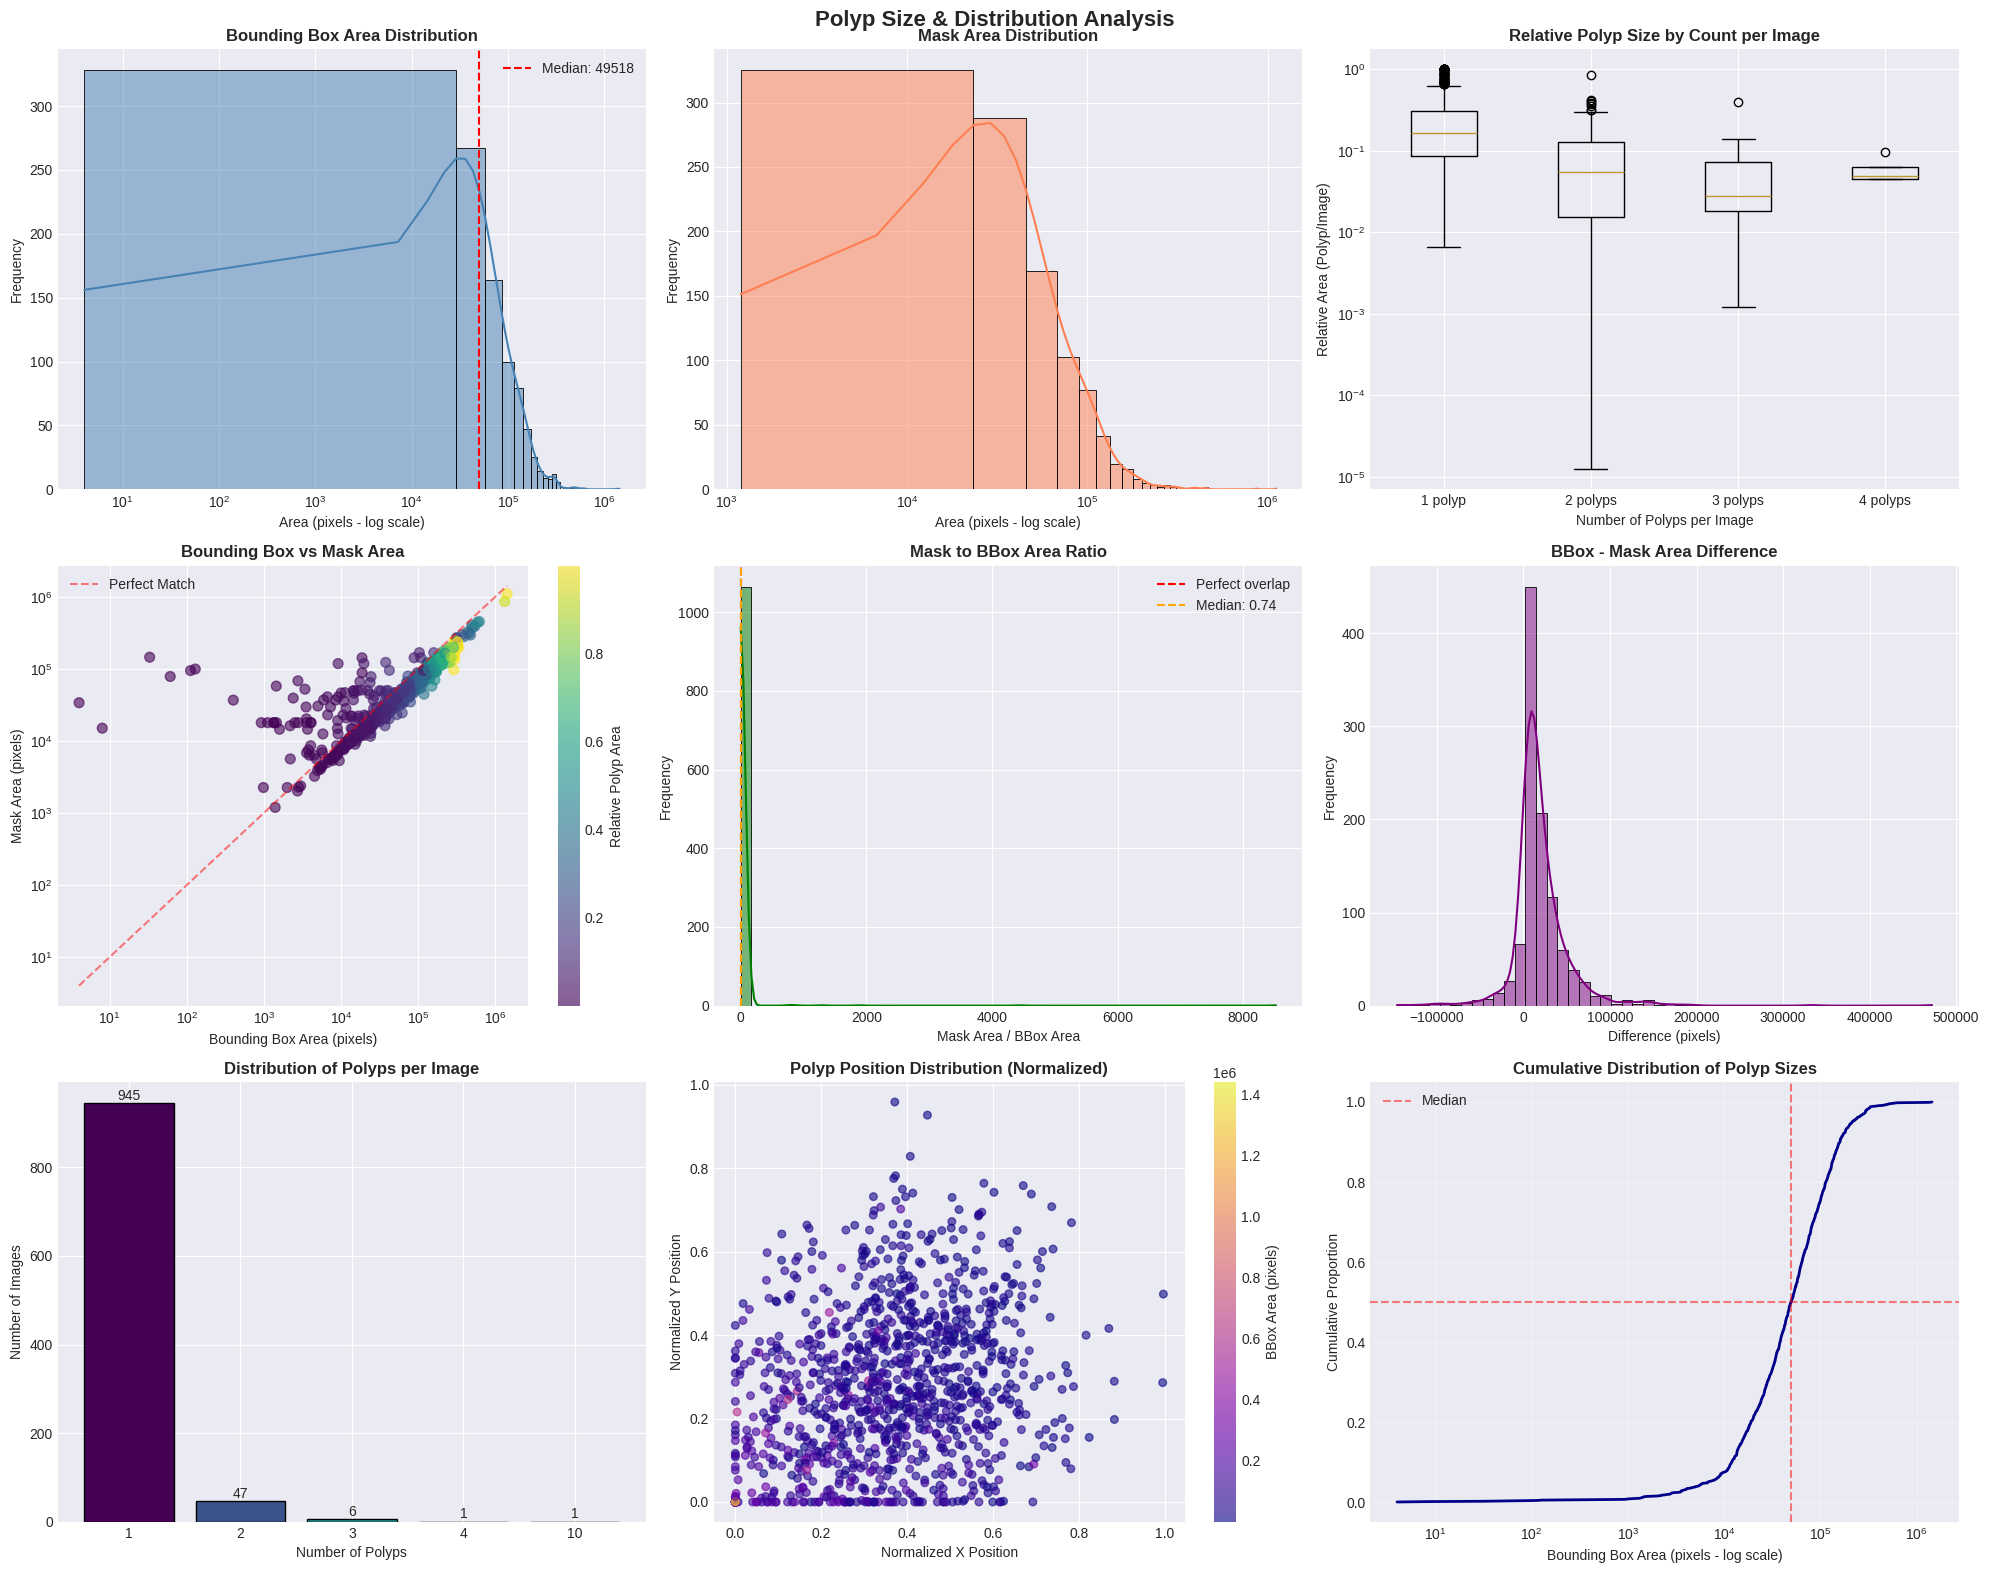

In [ ]:
# BLOCK 7.1: Figure 1 - Size and Distribution Analysis
# Set style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
# Create Figure 1 (3x3 grid)
fig1 = plt.figure(figsize=(20, 16))
fig1.suptitle('Polyp Size & Distribution Analysis', fontsize=16, fontweight='bold', y=0.98)

# 1.1: Bounding Box Area Distribution (Histogram + KDE)
ax1 = fig1.add_subplot(3, 3, 1)
sns.histplot(data=pandas_df, x='bbox_area', bins=50, kde=True, ax=ax1, color='steelblue')
ax1.set_xscale('log')
ax1.set_title('Bounding Box Area Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Area (pixels - log scale)')
ax1.set_ylabel('Frequency')
ax1.axvline(pandas_df['bbox_area'].median(), color='red', linestyle='--', label=f'Median: {pandas_df["bbox_area"].median():.0f}')
ax1.legend()

# 1.2: Mask Area Distribution (where available)
ax2 = fig1.add_subplot(3, 3, 2)
mask_valid = pandas_df[pandas_df['mask_area'] > 0]
if len(mask_valid) > 0:
    sns.histplot(data=mask_valid, x='mask_area', bins=50, kde=True, ax=ax2, color='coral')
    ax2.set_xscale('log')
    ax2.set_title('Mask Area Distribution', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Area (pixels - log scale)')
    ax2.set_ylabel('Frequency')
else:
    ax2.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax2.transAxes)

# 1.3: Relative Polyp Size (Boxplot by Polyp Count)
ax3 = fig1.add_subplot(3, 3, 3)
pandas_df['polyp_count'] = pandas_df.groupby('image_id')['image_id'].transform('count')
box_data = [pandas_df[pandas_df['polyp_count'] == i]['relative_bbox_area'].dropna() 
            for i in sorted(pandas_df['polyp_count'].unique()) if i <= 5]
if box_data:
    bp = ax3.boxplot(box_data, tick_labels=[f'{i} polyp{"s" if i>1 else ""}' for i in sorted(pandas_df['polyp_count'].unique()) if i <= 5])
    ax3.set_title('Relative Polyp Size by Count per Image', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Number of Polyps per Image')
    ax3.set_ylabel('Relative Area (Polyp/Image)')
    ax3.set_yscale('log')

# 1.4: BBox vs Mask Area Comparison (Scatter)
ax4 = fig1.add_subplot(3, 3, 4)
if len(mask_valid) > 0:
    scatter = ax4.scatter(mask_valid['bbox_area'], mask_valid['mask_area'], 
                          c=mask_valid['relative_bbox_area'], cmap='viridis', 
                          alpha=0.6, s=50)
    ax4.plot([mask_valid['bbox_area'].min(), mask_valid['bbox_area'].max()],
             [mask_valid['bbox_area'].min(), mask_valid['bbox_area'].max()], 
             'r--', alpha=0.5, label='Perfect Match')
    ax4.set_xscale('log')
    ax4.set_yscale('log')
    ax4.set_title('Bounding Box vs Mask Area', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Bounding Box Area (pixels)')
    ax4.set_ylabel('Mask Area (pixels)')
    ax4.legend()
    plt.colorbar(scatter, ax=ax4, label='Relative Polyp Area')
else:
    ax4.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax4.transAxes)

# 1.5: Area Ratio Distribution (Mask/BBox)
ax5 = fig1.add_subplot(3, 3, 5)
if len(mask_valid) > 0:
    sns.histplot(data=mask_valid, x='mask_vs_bbox_area_ratio', bins=50, kde=True, ax=ax5, color='green')
    ax5.axvline(1.0, color='red', linestyle='--', label='Perfect overlap')
    ax5.axvline(mask_valid['mask_vs_bbox_area_ratio'].median(), color='orange', linestyle='--', 
                label=f'Median: {mask_valid["mask_vs_bbox_area_ratio"].median():.2f}')
    ax5.set_title('Mask to BBox Area Ratio', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Mask Area / BBox Area')
    ax5.set_ylabel('Frequency')
    ax5.legend()
else:
    ax5.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax5.transAxes)

# 1.6: Area Difference Distribution
ax6 = fig1.add_subplot(3, 3, 6)
if len(mask_valid) > 0:
    sns.histplot(data=mask_valid, x='bbox_vs_mask_area_diff', bins=50, kde=True, ax=ax6, color='purple')
    ax6.set_title('BBox - Mask Area Difference', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Difference (pixels)')
    ax6.set_ylabel('Frequency')
else:
    ax6.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax6.transAxes)

# 1.7: Polyp Count Distribution (Bar plot)
ax7 = fig1.add_subplot(3, 3, 7)
polyp_counts = pandas_df.groupby('image_id').size().value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, len(polyp_counts)))
bars = ax7.bar(polyp_counts.index.astype(str), polyp_counts.values, color=colors, edgecolor='black')
ax7.set_title('Distribution of Polyps per Image', fontsize=12, fontweight='bold')
ax7.set_xlabel('Number of Polyps')
ax7.set_ylabel('Number of Images')
for i, (bar, count) in enumerate(zip(bars, polyp_counts.values)):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(count), 
             ha='center', va='bottom', fontsize=10)

# 1.8: Polyp Size Distribution by Position (xmin normalized)
ax8 = fig1.add_subplot(3, 3, 8)
pandas_df['norm_x'] = pandas_df['bbox_xmin'] / pandas_df['image_width']
pandas_df['norm_y'] = pandas_df['bbox_ymin'] / pandas_df['image_height']
scatter = ax8.scatter(pandas_df['norm_x'], pandas_df['norm_y'], 
                      c=pandas_df['bbox_area'], cmap='plasma', alpha=0.6, s=30)
ax8.set_title('Polyp Position Distribution (Normalized)', fontsize=12, fontweight='bold')
ax8.set_xlabel('Normalized X Position')
ax8.set_ylabel('Normalized Y Position')
plt.colorbar(scatter, ax=ax8, label='BBox Area (pixels)')

# 1.9: Cumulative Distribution of Polyp Sizes
ax9 = fig1.add_subplot(3, 3, 9)
sorted_areas = np.sort(pandas_df['bbox_area'])
cumulative = np.arange(1, len(sorted_areas)+1) / len(sorted_areas)
ax9.plot(sorted_areas, cumulative, linewidth=2, color='darkblue')
ax9.set_xscale('log')
ax9.set_title('Cumulative Distribution of Polyp Sizes', fontsize=12, fontweight='bold')
ax9.set_xlabel('Bounding Box Area (pixels - log scale)')
ax9.set_ylabel('Cumulative Proportion')
ax9.grid(True, alpha=0.3)
ax9.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Median')
ax9.axvline(x=pandas_df['bbox_area'].median(), color='red', linestyle='--', alpha=0.5)
ax9.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_size_distribution.png", dpi=150, bbox_inches='tight')
print(f"Figure 1 saved: {OUTPUT_DIR / 'fig1_size_distribution.png'}")
plt.show()

Figure 2 saved: /home/srirama/Documents/sr_proj/PolypDetection/notebooks/1-explore/outputs/fig2_shape_morphology.png


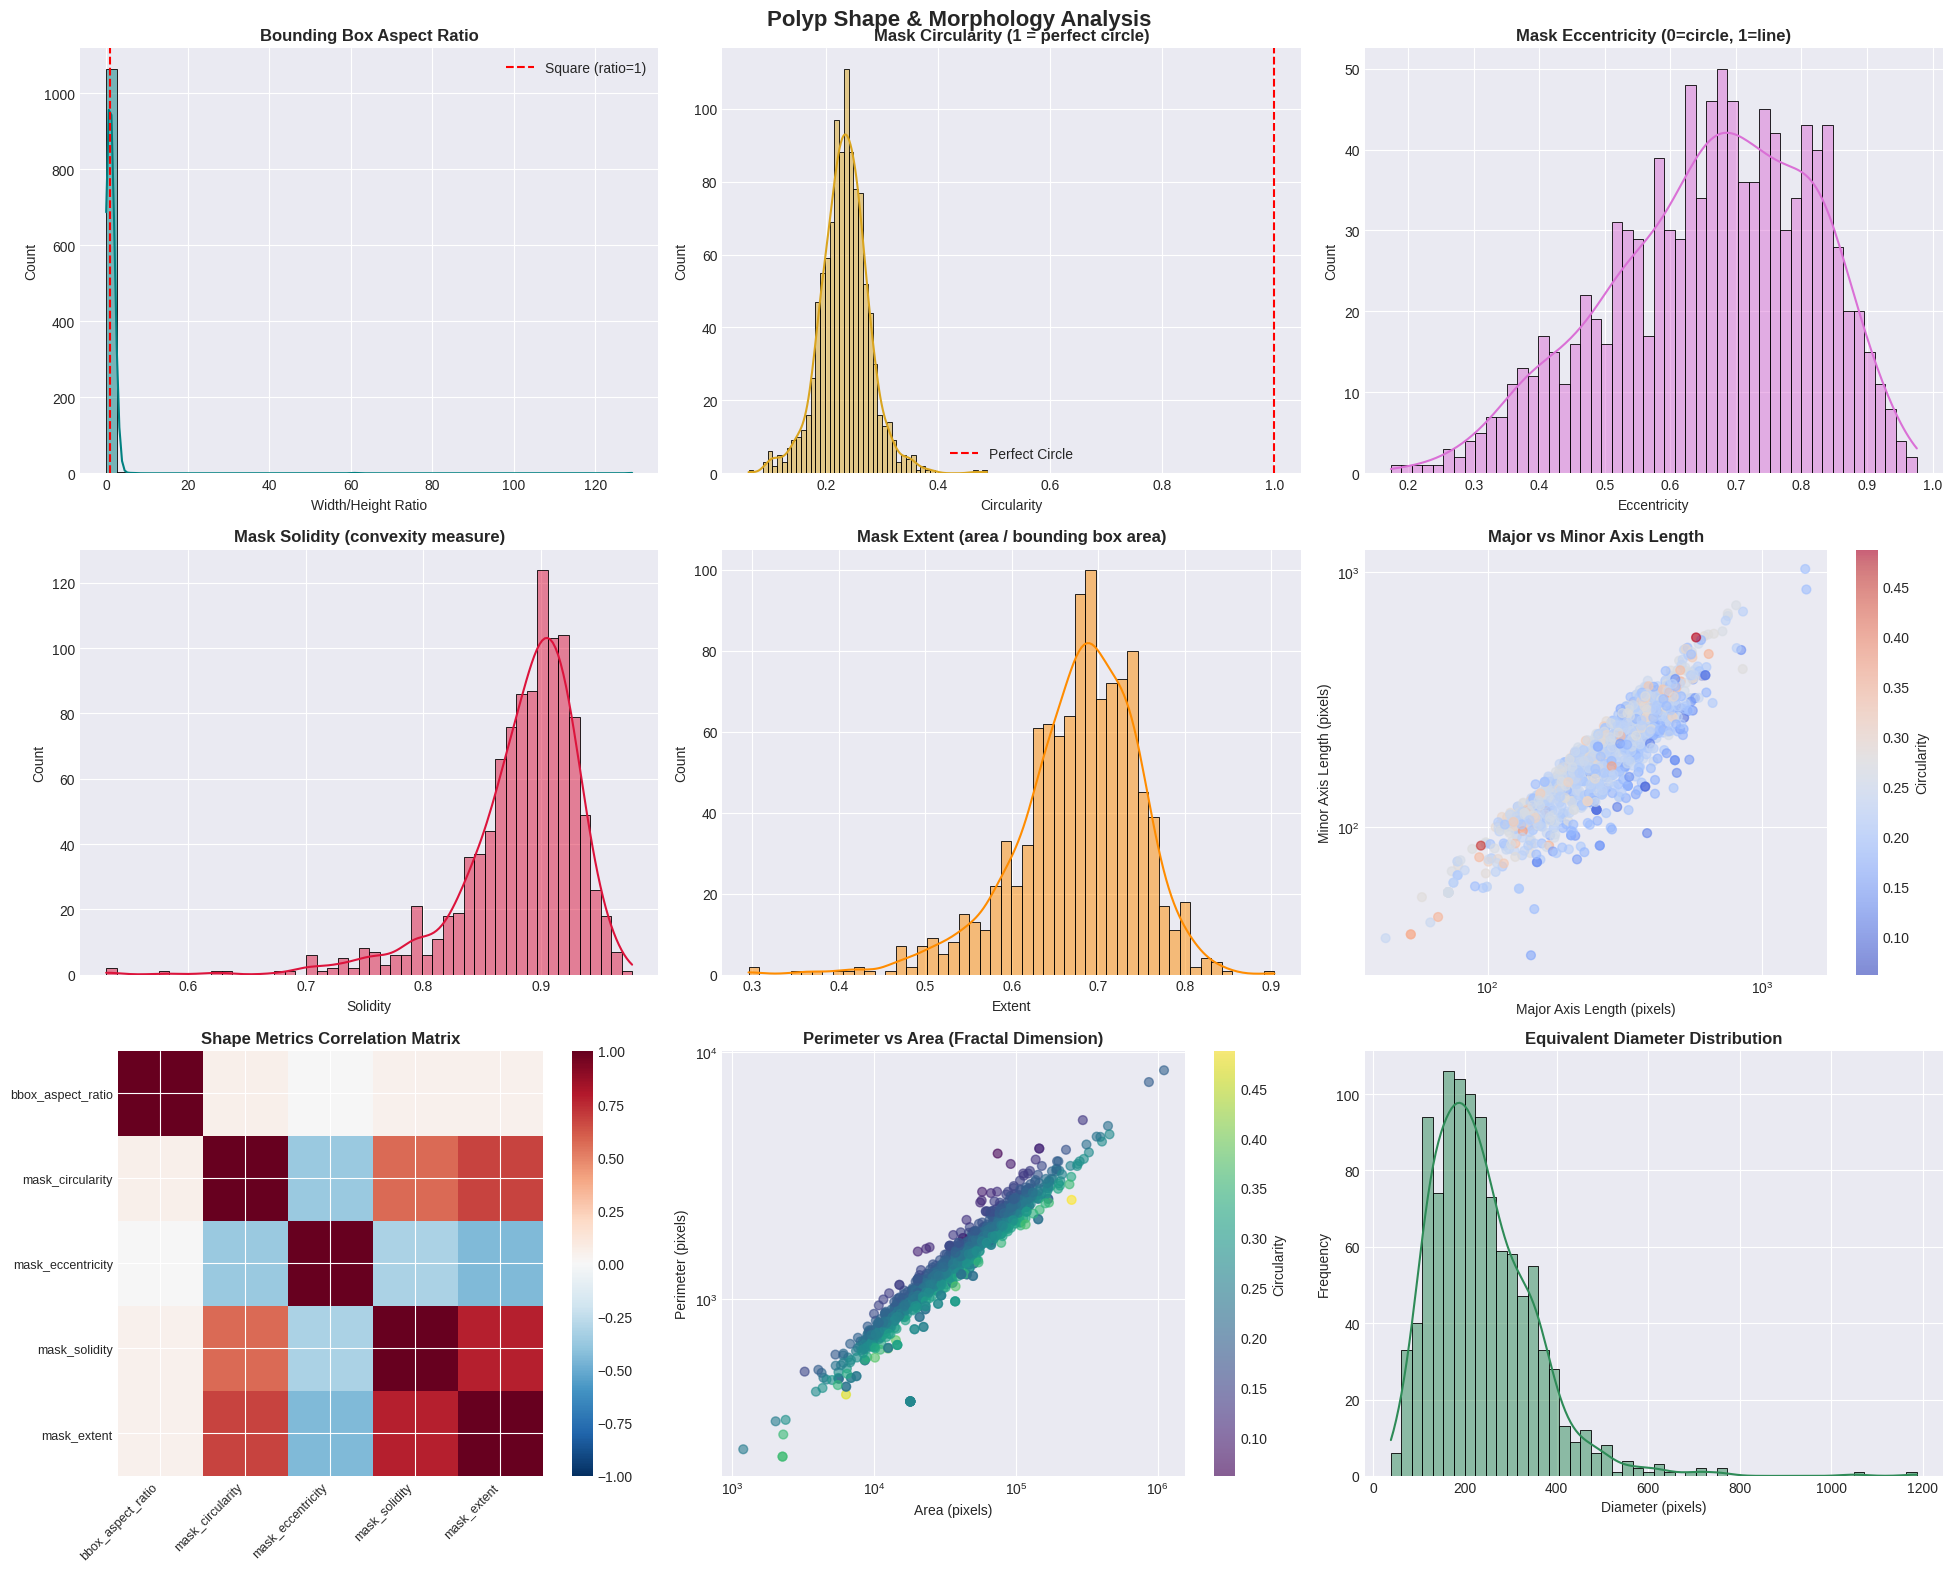

In [22]:
# BLOCK 7.2: Figure 2 - Shape and Morphology Analysis
fig2 = plt.figure(figsize=(20, 16))
fig2.suptitle('Polyp Shape & Morphology Analysis', fontsize=16, fontweight='bold', y=0.98)

# 2.1: Aspect Ratio Distribution
ax1 = fig2.add_subplot(3, 3, 1)
sns.histplot(data=pandas_df, x='bbox_aspect_ratio', bins=50, kde=True, ax=ax1, color='teal')
ax1.axvline(1.0, color='red', linestyle='--', label='Square (ratio=1)')
ax1.set_title('Bounding Box Aspect Ratio', fontsize=12, fontweight='bold')
ax1.set_xlabel('Width/Height Ratio')
ax1.legend()

# 2.2: Mask Circularity Distribution
ax2 = fig2.add_subplot(3, 3, 2)
if len(mask_valid) > 0:
    sns.histplot(data=mask_valid, x='mask_circularity', bins=50, kde=True, ax=ax2, color='goldenrod')
    ax2.axvline(1.0, color='red', linestyle='--', label='Perfect Circle')
    ax2.set_title('Mask Circularity (1 = perfect circle)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Circularity')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax2.transAxes)

# 2.3: Mask Eccentricity Distribution
ax3 = fig2.add_subplot(3, 3, 3)
if len(mask_valid) > 0:
    sns.histplot(data=mask_valid, x='mask_eccentricity', bins=50, kde=True, ax=ax3, color='orchid')
    ax3.set_title('Mask Eccentricity (0=circle, 1=line)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Eccentricity')
else:
    ax3.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax3.transAxes)

# 2.4: Mask Solidity Distribution
ax4 = fig2.add_subplot(3, 3, 4)
if len(mask_valid) > 0:
    sns.histplot(data=mask_valid, x='mask_solidity', bins=50, kde=True, ax=ax4, color='crimson')
    ax4.set_title('Mask Solidity (convexity measure)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Solidity')
else:
    ax4.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax4.transAxes)

# 2.5: Mask Extent Distribution
ax5 = fig2.add_subplot(3, 3, 5)
if len(mask_valid) > 0:
    sns.histplot(data=mask_valid, x='mask_extent', bins=50, kde=True, ax=ax5, color='darkorange')
    ax5.set_title('Mask Extent (area / bounding box area)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Extent')
else:
    ax5.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax5.transAxes)

# 2.6: Major vs Minor Axis (Scatter)
ax6 = fig2.add_subplot(3, 3, 6)
if len(mask_valid) > 0:
    scatter = ax6.scatter(mask_valid['mask_major_axis'], mask_valid['mask_minor_axis'], 
                          c=mask_valid['mask_circularity'], cmap='coolwarm', alpha=0.6, s=40)
    ax6.set_xscale('log')
    ax6.set_yscale('log')
    ax6.set_title('Major vs Minor Axis Length', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Major Axis Length (pixels)')
    ax6.set_ylabel('Minor Axis Length (pixels)')
    plt.colorbar(scatter, ax=ax6, label='Circularity')
else:
    ax6.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax6.transAxes)

# 2.7: Shape Metrics Correlation Heatmap
ax7 = fig2.add_subplot(3, 3, 7)
shape_metrics = ['bbox_aspect_ratio', 'mask_circularity', 'mask_eccentricity', 
                 'mask_solidity', 'mask_extent']
if len(mask_valid) > 0:
    corr_matrix = mask_valid[shape_metrics].corr()
    im = ax7.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax7.set_xticks(range(len(shape_metrics)))
    ax7.set_yticks(range(len(shape_metrics)))
    ax7.set_xticklabels(shape_metrics, rotation=45, ha='right', fontsize=9)
    ax7.set_yticklabels(shape_metrics, fontsize=9)
    ax7.set_title('Shape Metrics Correlation Matrix', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax7)
else:
    ax7.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax7.transAxes)

# 2.8: Perimeter vs Area Relationship
ax8 = fig2.add_subplot(3, 3, 8)
if len(mask_valid) > 0:
    scatter = ax8.scatter(mask_valid['mask_area'], mask_valid['mask_perimeter'], 
                          c=mask_valid['mask_circularity'], cmap='viridis', alpha=0.6, s=40)
    ax8.set_xscale('log')
    ax8.set_yscale('log')
    ax8.set_title('Perimeter vs Area (Fractal Dimension)', fontsize=12, fontweight='bold')
    ax8.set_xlabel('Area (pixels)')
    ax8.set_ylabel('Perimeter (pixels)')
    plt.colorbar(scatter, ax=ax8, label='Circularity')
else:
    ax8.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax8.transAxes)

# 2.9: Equivalent Diameter Distribution
ax9 = fig2.add_subplot(3, 3, 9)
if len(mask_valid) > 0:
    sns.histplot(data=mask_valid, x='mask_eq_diameter', bins=50, kde=True, ax=ax9, color='seagreen')
    ax9.set_title('Equivalent Diameter Distribution', fontsize=12, fontweight='bold')
    ax9.set_xlabel('Diameter (pixels)')
    ax9.set_ylabel('Frequency')
else:
    ax9.text(0.5, 0.5, 'No mask data available', ha='center', va='center', transform=ax9.transAxes)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_shape_morphology.png", dpi=150, bbox_inches='tight')
print(f"Figure 2 saved: {OUTPUT_DIR / 'fig2_shape_morphology.png'}")
plt.show()

/tmp/ipykernel_5808/1331444091.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rgb_means, x='Channel', y='Mean Value', ax=ax4, palette='Set2')
/tmp/ipykernel_5808/1331444091.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rgb_stds, x='Channel', y='Std Value', ax=ax5, palette='Set1')


Figure 3 saved: /home/srirama/Documents/sr_proj/PolypDetection/notebooks/1-explore/outputs/fig3_quality_color.png


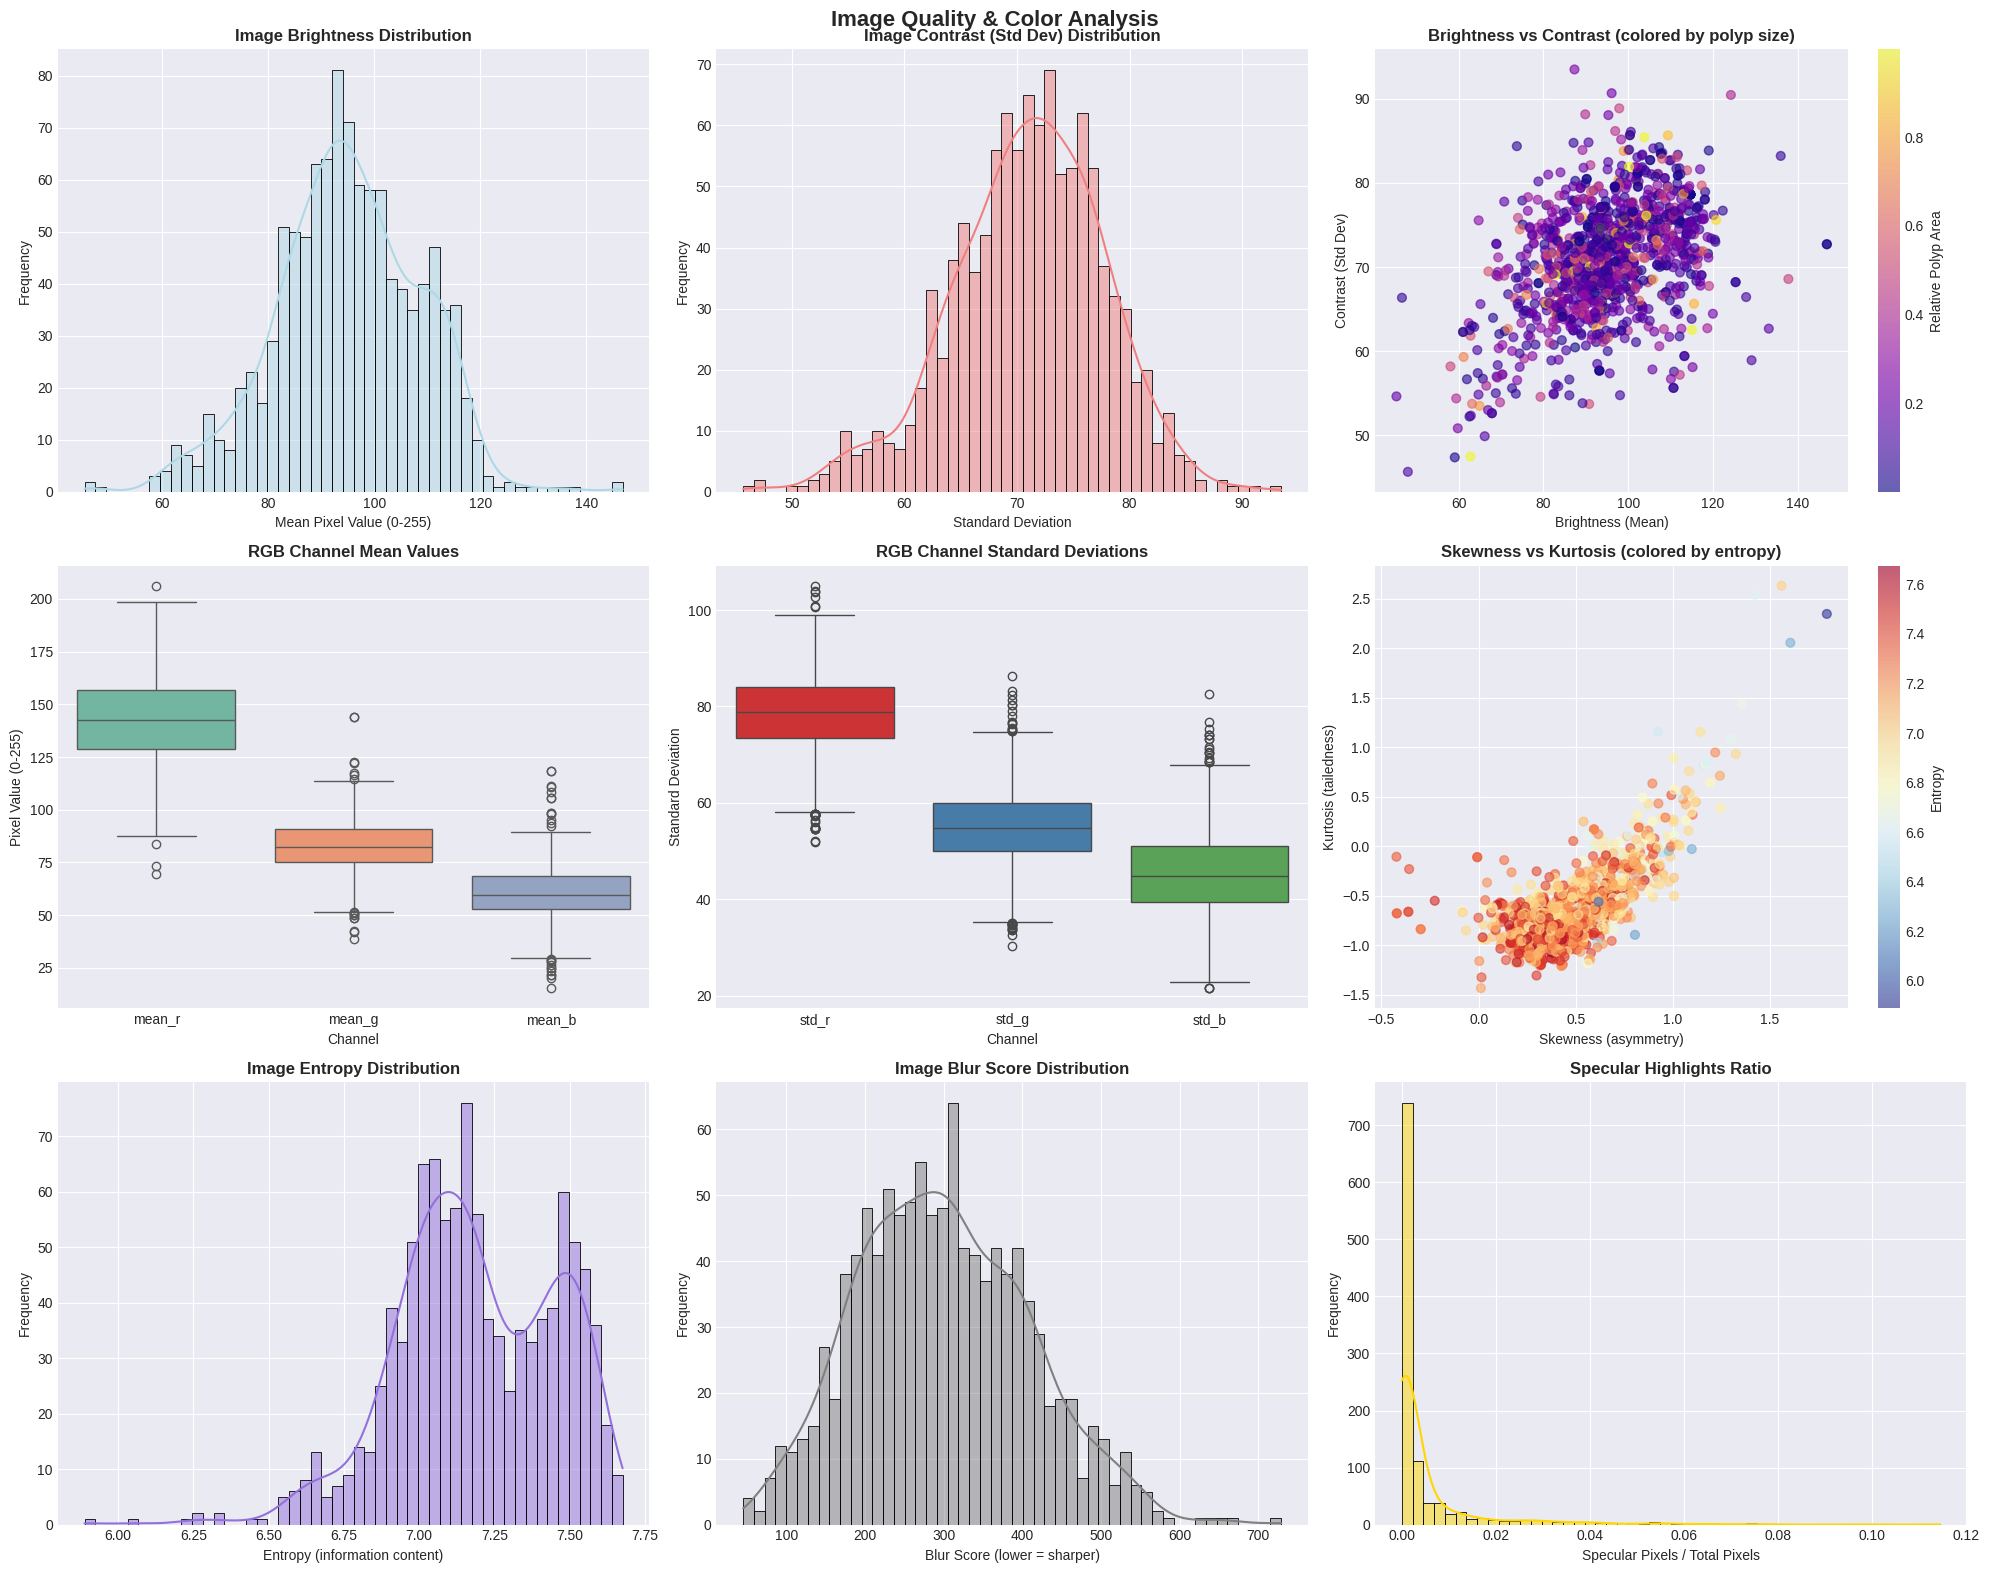

In [23]:
# BLOCK 7.3: Figure 3 - Image Quality and Color Analysis
fig3 = plt.figure(figsize=(20, 16))
fig3.suptitle('Image Quality & Color Analysis', fontsize=16, fontweight='bold', y=0.98)

# 3.1: Brightness Distribution
ax1 = fig3.add_subplot(3, 3, 1)
sns.histplot(data=pandas_df, x='image_brightness_mean', bins=50, kde=True, ax=ax1, color='lightblue')
ax1.set_title('Image Brightness Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mean Pixel Value (0-255)')
ax1.set_ylabel('Frequency')

# 3.2: Contrast Distribution
ax2 = fig3.add_subplot(3, 3, 2)
sns.histplot(data=pandas_df, x='image_contrast_std', bins=50, kde=True, ax=ax2, color='lightcoral')
ax2.set_title('Image Contrast (Std Dev) Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Standard Deviation')
ax2.set_ylabel('Frequency')

# 3.3: Brightness vs Contrast Scatter
ax3 = fig3.add_subplot(3, 3, 3)
scatter = ax3.scatter(pandas_df['image_brightness_mean'], pandas_df['image_contrast_std'], 
                      c=pandas_df['relative_bbox_area'], cmap='plasma', alpha=0.6, s=40)
ax3.set_title('Brightness vs Contrast (colored by polyp size)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Brightness (Mean)')
ax3.set_ylabel('Contrast (Std Dev)')
plt.colorbar(scatter, ax=ax3, label='Relative Polyp Area')

# 3.4: RGB Channel Means (Boxplot)
ax4 = fig3.add_subplot(3, 3, 4)
rgb_means = pandas_df[['mean_r', 'mean_g', 'mean_b']].melt(var_name='Channel', value_name='Mean Value')
sns.boxplot(data=rgb_means, x='Channel', y='Mean Value', ax=ax4, palette='Set2')
ax4.set_title('RGB Channel Mean Values', fontsize=12, fontweight='bold')
ax4.set_ylabel('Pixel Value (0-255)')

# 3.5: RGB Channel Standard Deviations (Boxplot)
ax5 = fig3.add_subplot(3, 3, 5)
rgb_stds = pandas_df[['std_r', 'std_g', 'std_b']].melt(var_name='Channel', value_name='Std Value')
sns.boxplot(data=rgb_stds, x='Channel', y='Std Value', ax=ax5, palette='Set1')
ax5.set_title('RGB Channel Standard Deviations', fontsize=12, fontweight='bold')
ax5.set_ylabel('Standard Deviation')

# 3.6: Skewness vs Kurtosis
ax6 = fig3.add_subplot(3, 3, 6)
scatter = ax6.scatter(pandas_df['image_skewness'], pandas_df['image_kurtosis'], 
                      c=pandas_df['image_entropy'], cmap='RdYlBu_r', alpha=0.6, s=40)
ax6.set_title('Skewness vs Kurtosis (colored by entropy)', fontsize=12, fontweight='bold')
ax6.set_xlabel('Skewness (asymmetry)')
ax6.set_ylabel('Kurtosis (tailedness)')
plt.colorbar(scatter, ax=ax6, label='Entropy')

# 3.7: Entropy Distribution
ax7 = fig3.add_subplot(3, 3, 7)
sns.histplot(data=pandas_df, x='image_entropy', bins=50, kde=True, ax=ax7, color='mediumpurple')
ax7.set_title('Image Entropy Distribution', fontsize=12, fontweight='bold')
ax7.set_xlabel('Entropy (information content)')
ax7.set_ylabel('Frequency')

# 3.8: Blur Score Distribution
ax8 = fig3.add_subplot(3, 3, 8)
sns.histplot(data=pandas_df, x='image_blur_score', bins=50, kde=True, ax=ax8, color='gray')
ax8.set_title('Image Blur Score Distribution', fontsize=12, fontweight='bold')
ax8.set_xlabel('Blur Score (lower = sharper)')
ax8.set_ylabel('Frequency')

# 3.9: Specular Highlights Distribution
ax9 = fig3.add_subplot(3, 3, 9)
sns.histplot(data=pandas_df, x='specular_ratio', bins=50, kde=True, ax=ax9, color='gold')
ax9.set_title('Specular Highlights Ratio', fontsize=12, fontweight='bold')
ax9.set_xlabel('Specular Pixels / Total Pixels')
ax9.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_quality_color.png", dpi=150, bbox_inches='tight')
print(f"Figure 3 saved: {OUTPUT_DIR / 'fig3_quality_color.png'}")
plt.show()

In [24]:
# BLOCK 8: Enhanced Outlier Detection with Tabulate
from tabulate import tabulate


print("OUTLIER DETECTION ANALYSIS")


def detect_outliers_iqr(data, column, threshold=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers for multiple metrics
outlier_metrics = {
    'Polyp Size (bbox_area)': 'bbox_area',
    'Relative Polyp Size': 'relative_bbox_area',
    'Image Brightness': 'image_brightness_mean',
    'Image Contrast': 'image_contrast_std',
    'Mask Circularity': 'mask_circularity',
    'Image Blur Score': 'image_blur_score',
    'Specular Ratio': 'specular_ratio'
}

outlier_results = []
for name, column in outlier_metrics.items():
    if column in pandas_df.columns:
        valid_data = pandas_df[pandas_df[column].notna()]
        if len(valid_data) > 0:
            outliers, lb, ub = detect_outliers_iqr(valid_data, column)
            outlier_results.append([
                name, 
                len(outliers), 
                f"{len(outliers)/len(valid_data)*100:.2f}%",
                f"{lb:.3f}",
                f"{ub:.3f}"
            ])

print("\n📊 Outlier Summary by Metric")
print(tabulate(outlier_results, 
               headers=["Metric", "# Outliers", "Percentage", "Lower Bound", "Upper Bound"],
               tablefmt="grid"))

# Find extreme cases
print("\n🎯 EXTREME CASES")


# Smallest and largest polyps
smallest_idx = pandas_df['bbox_area'].idxmin()
largest_idx = pandas_df['bbox_area'].idxmax()

extreme_cases = [
    ["Smallest Polyp", pandas_df.loc[smallest_idx, 'unique_polyp_id'], 
     f"{pandas_df.loc[smallest_idx, 'bbox_area']:.0f} px"],
    ["Largest Polyp", pandas_df.loc[largest_idx, 'unique_polyp_id'], 
     f"{pandas_df.loc[largest_idx, 'bbox_area']:.0f} px"],
]

# Most and least circular (if mask data exists)
if 'mask_circularity' in pandas_df.columns:
    valid_circle = pandas_df[pandas_df['mask_circularity'].notna() & (pandas_df['mask_circularity'] > 0)]
    if len(valid_circle) > 0:
        most_circular_idx = valid_circle['mask_circularity'].idxmax()
        least_circular_idx = valid_circle['mask_circularity'].idxmin()
        extreme_cases.extend([
            ["Most Circular Polyp", pandas_df.loc[most_circular_idx, 'unique_polyp_id'], 
             f"{pandas_df.loc[most_circular_idx, 'mask_circularity']:.3f}"],
            ["Least Circular Polyp", pandas_df.loc[least_circular_idx, 'unique_polyp_id'], 
             f"{pandas_df.loc[least_circular_idx, 'mask_circularity']:.3f}"],
        ])

# Darkest and brightest images
image_summary = pandas_df.groupby('image_id').agg({
    'image_brightness_mean': 'mean',
    'image_contrast_std': 'mean'
}).reset_index()
darkest_idx = image_summary['image_brightness_mean'].idxmin()
brightest_idx = image_summary['image_brightness_mean'].idxmax()

extreme_cases.extend([
    ["Darkest Image", image_summary.loc[darkest_idx, 'image_id'], 
     f"{image_summary.loc[darkest_idx, 'image_brightness_mean']:.2f}"],
    ["Brightest Image", image_summary.loc[brightest_idx, 'image_id'], 
     f"{image_summary.loc[brightest_idx, 'image_brightness_mean']:.2f}"],
])

print(tabulate(extreme_cases, headers=["Category", "ID", "Value"], tablefmt="grid"))

# Save outlier images list
outlier_images = pd.DataFrame({
    'image_id': [image_summary.loc[darkest_idx, 'image_id'], image_summary.loc[brightest_idx, 'image_id']],
    'reason': ['darkest_image', 'brightest_image'],
    'value': [image_summary.loc[darkest_idx, 'image_brightness_mean'], 
              image_summary.loc[brightest_idx, 'image_brightness_mean']]
})

# Add outlier images based on other metrics
for name, col in [('low_contrast', 'image_contrast_std'), ('high_blur', 'image_blur_score')]:
    if col in pandas_df.columns:
        q1 = pandas_df[col].quantile(0.05)
        q99 = pandas_df[col].quantile(0.95)
        if col == 'image_contrast_std':
            extreme_images = pandas_df[pandas_df[col] < q1]['image_id'].unique()[:3]
            for img in extreme_images:
                outlier_images = pd.concat([outlier_images, pd.DataFrame([{
                    'image_id': img, 'reason': name, 'value': pandas_df[pandas_df['image_id']==img][col].mean()
                }])])
        else:
            extreme_images = pandas_df[pandas_df[col] > q99]['image_id'].unique()[:3]
            for img in extreme_images:
                outlier_images = pd.concat([outlier_images, pd.DataFrame([{
                    'image_id': img, 'reason': name, 'value': pandas_df[pandas_df['image_id']==img][col].mean()
                }])])

outlier_images.to_csv(OUTPUT_DIR / 'outlier_images.csv', index=False)
print(f"\nOutlier list saved: {OUTPUT_DIR / 'outlier_images.csv'}")

OUTLIER DETECTION ANALYSIS

📊 Outlier Summary by Metric
+------------------------+--------------+--------------+---------------+---------------+
| Metric                 |   # Outliers | Percentage   |   Lower Bound |   Upper Bound |
+========================+==============+==============+===============+===============+
| Polyp Size (bbox_area) |           57 | 5.32%        |    -87887.2   |    210451     |
+------------------------+--------------+--------------+---------------+---------------+
| Relative Polyp Size    |           45 | 4.20%        |        -0.26  |         0.629 |
+------------------------+--------------+--------------+---------------+---------------+
| Image Brightness       |           12 | 1.12%        |        59.904 |       131.38  |
+------------------------+--------------+--------------+---------------+---------------+
| Image Contrast         |           13 | 1.21%        |        53.446 |        88.983 |
+------------------------+--------------+-------------